# Netflix Data Analysis Project

## Objective
Analyze Netflix titles data using Python and find useful insights about Movies, TV Shows, countries, ratings, categories, and release trends.

**Dataset:** `data/netflix_titles.csv`

## 1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show charts inside notebook
%matplotlib inline

## 2. Load Dataset

In [12]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Basic Dataset Information

In [13]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.info()

Rows and Columns: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## 4. Check Missing Values

In [14]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## 5. Data Cleaning

We will clean important columns and convert `date_added` into a proper date format.

In [15]:
# Fill missing values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

# Convert date_added column to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Create new columns
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


## 6. Movies vs TV Shows

In [16]:
type_count = df["type"].value_counts()
type_count

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

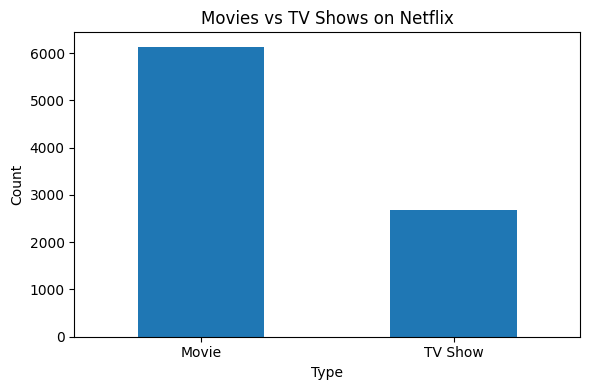

In [18]:
plt.figure(figsize=(6,4))
type_count.plot(kind="bar")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/movies_vs_tvshows.png")
plt.show()

## 7. Top 10 Countries by Number of Titles

In [19]:
# Some titles have multiple countries. We split them for better analysis.
country_series = df["country"].dropna().str.split(", ").explode()
top_countries = country_series[country_series != "Unknown"].value_counts().head(10)
top_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

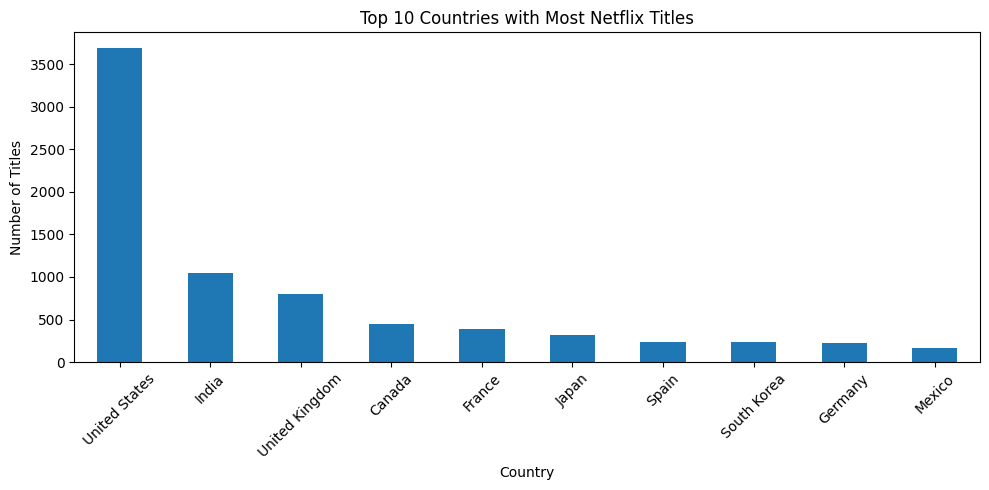

In [21]:
plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries with Most Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/top_10_countries.png")
plt.show()

## 8. Titles Released by Year

In [20]:
release_trend = df["release_year"].value_counts().sort_index()
release_trend.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(12,5))
release_trend.plot(kind="line")
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("outputs/release_year_trend.png")
plt.show()

## 9. Top 10 Ratings

In [22]:
top_ratings = df["rating"].value_counts().head(10)
top_ratings

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(9,5))
top_ratings.plot(kind="bar")
plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/top_10_ratings.png")
plt.show()

## 10. Top 10 Categories / Genres

In [23]:
genre_series = df["listed_in"].str.split(", ").explode()
top_genres = genre_series.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

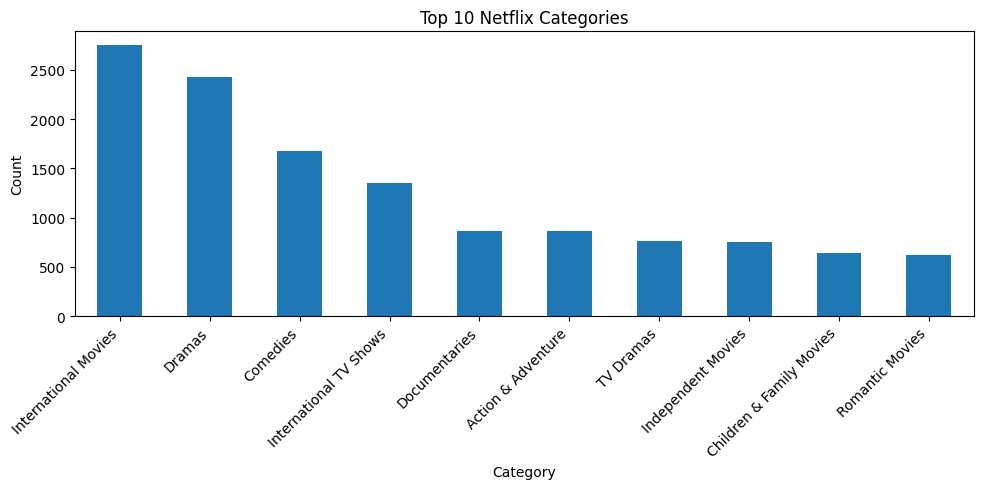

In [24]:
plt.figure(figsize=(10,5))
top_genres.plot(kind="bar")
plt.title("Top 10 Netflix Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/top_10_categories.png")
plt.show()

## 11. Netflix Content Added by Year

In [25]:
added_year_count = df["year_added"].dropna().astype(int).value_counts().sort_index()
added_year_count

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64

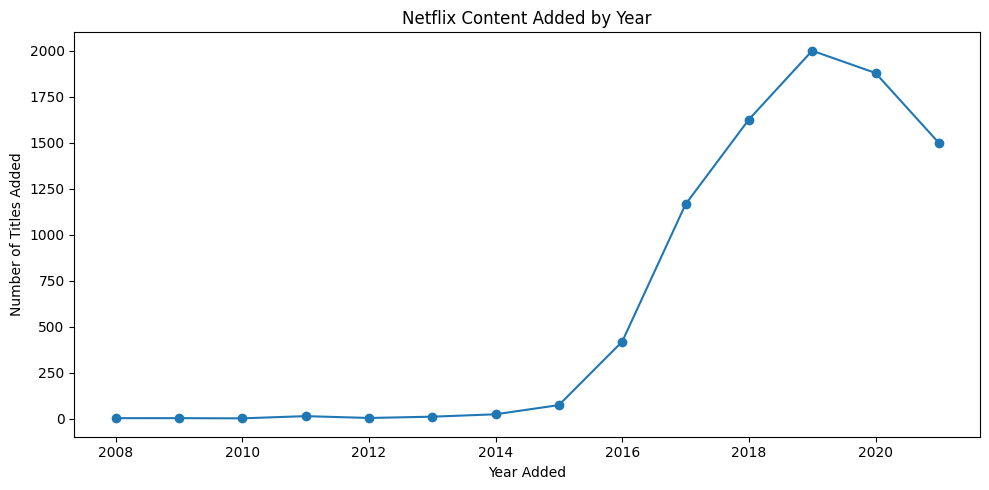

In [26]:
plt.figure(figsize=(10,5))
added_year_count.plot(kind="line", marker="o")
plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig("outputs/content_added_by_year.png")
plt.show()

## 12. Key Insights

After running this notebook, you can write insights like:

- Netflix has more Movies than TV Shows.
- The United States has the highest number of Netflix titles.
- Content release increased strongly after 2000.
- TV-MA and TV-14 are among the most common ratings.
- International Movies, Dramas, and Comedies are common categories.

## Final Conclusion

This project shows how Python can be used for data cleaning, data analysis, and visualization. It is useful for a beginner Data Analyst portfolio project.